## Portfolio Design

This project uses a 70% stock and 30% bond portfolio as the baseline. The portfolio is growth oriented, but still includes bonds to reduce risk.

Baseline weights:

SPY: 50%  
QQQ: 15%  
IWM: 5%  
IEF: 20%  
TLT: 10%

## Data

The analysis uses daily ETF price data from 2010 to 2024. Prices are loaded from the clean dataset created in the data notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("../data")

prices = pd.read_csv(
    data_path / "etf_prices_clean.csv",
    parse_dates=["Date"],
    index_col="Date"
)

prices.head()

,SPY,QQQ,IWM,IEF,TLT
Date,,,,,
2010-01-04,84.578499,40.246552,51.244705,61.346455,55.722836
2010-01-05,84.802361,40.246552,51.068497,61.615871,56.082729
2010-01-06,84.862083,40.003796,51.020435,61.367188,55.331974
2010-01-07,85.220306,40.029812,51.396877,61.367188,55.425041
2010-01-08,85.503891,40.359272,51.677204,61.443161,55.400230


In [5]:
print(prices.index.min())
print(prices.index.max())
print(prices.shape)

prices.isna().sum()

2010-01-04 00:00:00
2024-12-30 00:00:00
(3773, 5)


SPY    0
QQQ    0
IWM    0
IEF    0
TLT    0
dtype: int64

## Return Calculation

Daily returns are calculated from ETF price changes. These returns are used to build the portfolio return series.

In [8]:
returns = prices.pct_change().dropna()

returns.head()

,SPY,QQQ,IWM,IEF,TLT
Date,,,,,
2010-01-05,0.002647,0.000000,-0.003439,0.004392,0.006459
2010-01-06,0.000704,-0.006032,-0.000941,-0.004036,-0.013387
2010-01-07,0.004221,0.000650,0.007378,0.000000,0.001682
2010-01-08,0.003328,0.008230,0.005454,0.001238,-0.000448
2010-01-11,0.001397,-0.004082,-0.004030,0.000674,-0.005489


In [10]:
returns.describe()

,SPY,QQQ,IWM,IEF,TLT
count,3772.000000,3772.000000,3772.000000,3772.000000,3772.000000
mean,0.000568,0.000757,0.000482,0.000104,0.000150
std,0.010742,0.012875,0.014028,0.004217,0.009629
min,-0.109424,-0.119788,-0.132669,-0.025073,-0.066683
25%,-0.003709,-0.004737,-0.006680,-0.002447,-0.005680
50%,0.000686,0.001170,0.001002,0.000213,0.000548
75%,0.005790,0.007351,0.008066,0.002587,0.005847
max,0.090603,0.084706,0.091492,0.026417,0.075195


## Portfolio Returns

The baseline portfolio return is calculated as the weighted average of ETF returns.

In [13]:
weights = pd.Series({
    "SPY": 0.50,
    "QQQ": 0.15,
    "IWM": 0.05,
    "IEF": 0.20,
    "TLT": 0.10
})

weights.sum()

1.0000000000000002

In [15]:
portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2010-01-05    0.002676
2010-01-06   -0.002746
2010-01-07    0.002745
2010-01-08    0.003374
2010-01-11   -0.000530
dtype: float64

## Cumulative Performance

Cumulative performance shows how one dollar invested in the portfolio would have grown over time.

In [18]:
cumulative_portfolio = (1 + portfolio_returns).cumprod()

cumulative_portfolio.head()

Date
2010-01-05    1.002676
2010-01-06    0.999923
2010-01-07    1.002668
2010-01-08    1.006051
2010-01-11    1.005518
dtype: float64

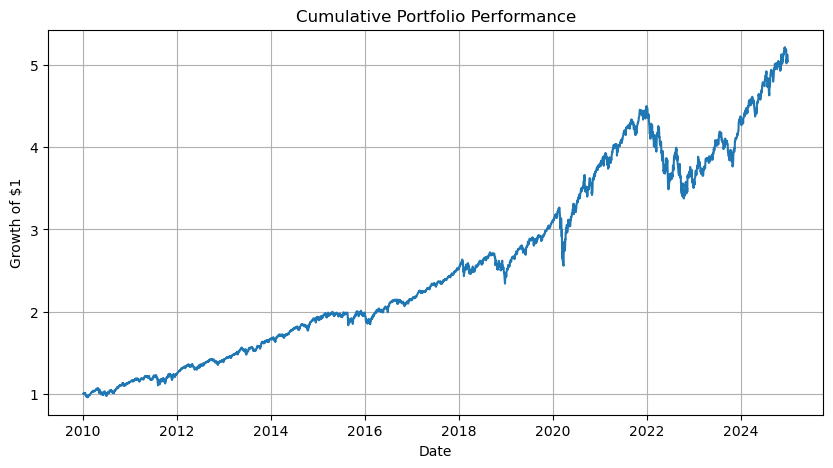

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_portfolio.index, cumulative_portfolio)
plt.title("Cumulative Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## Performance Metrics

This section calculates the main portfolio metrics, including annualized return, volatility, sharpe ratio, and maximum drawdown.

In [23]:
trading_days = 252
risk_free_rate = 0

annualized_return = (1 + portfolio_returns).prod() ** (trading_days / len(portfolio_returns)) - 1
annualized_volatility = portfolio_returns.std() * np.sqrt(trading_days)
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

running_max = cumulative_portfolio.cummax()
drawdown = cumulative_portfolio / running_max - 1
max_drawdown = drawdown.min()

metrics = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        annualized_return,
        annualized_volatility,
        sharpe_ratio,
        max_drawdown
    ]
})

metrics

,Metric,Value
0,Annualized Return,0.114216
1,Annualized Volatility,0.118921
2,Sharpe Ratio,0.960443
3,Maximum Drawdown,-0.249775


In [25]:
metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}")

metrics

,Metric,Value
0,Annualized Return,11.42%
1,Annualized Volatility,11.89%
2,Sharpe Ratio,96.04%
3,Maximum Drawdown,-24.98%


## Drawdown Analysis

Drawdown measures how far the portfolio falls from its previous peak. This helps show the size and timing of portfolio losses.

In [28]:
drawdown = cumulative_portfolio / cumulative_portfolio.cummax() - 1

drawdown.head()

Date
2010-01-05    0.000000
2010-01-06   -0.002746
2010-01-07   -0.000008
2010-01-08    0.000000
2010-01-11   -0.000530
dtype: float64

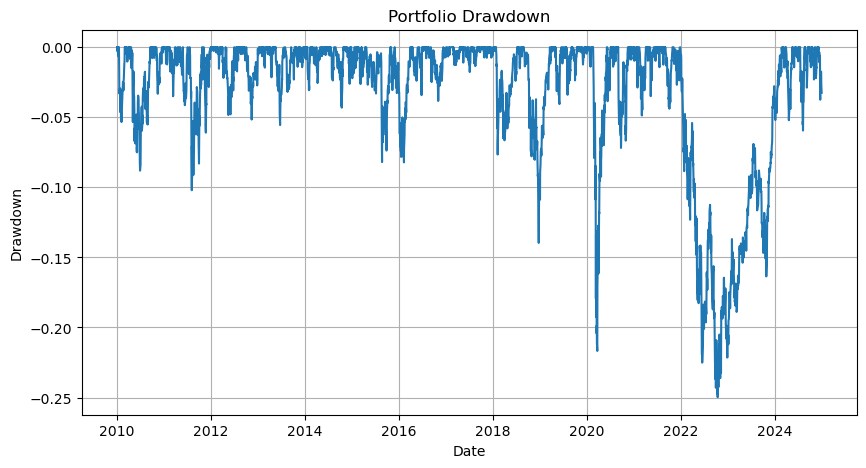

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(drawdown.index, drawdown)
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

Worst drawdown:

In [32]:
drawdown.min()

-0.24977542330038016

## Rolling Risk

Rolling volatility shows how portfolio risk changes over time. A 252 trading day window is used to estimate 12 month annualized volatility.

In [41]:
rolling_volatility = portfolio_returns.rolling(window=252).std() * np.sqrt(252)

rolling_volatility.dropna().head()

Date
2011-01-03    0.114746
2011-01-04    0.114732
2011-01-05    0.114685
2011-01-06    0.114665
2011-01-07    0.114630
dtype: float64

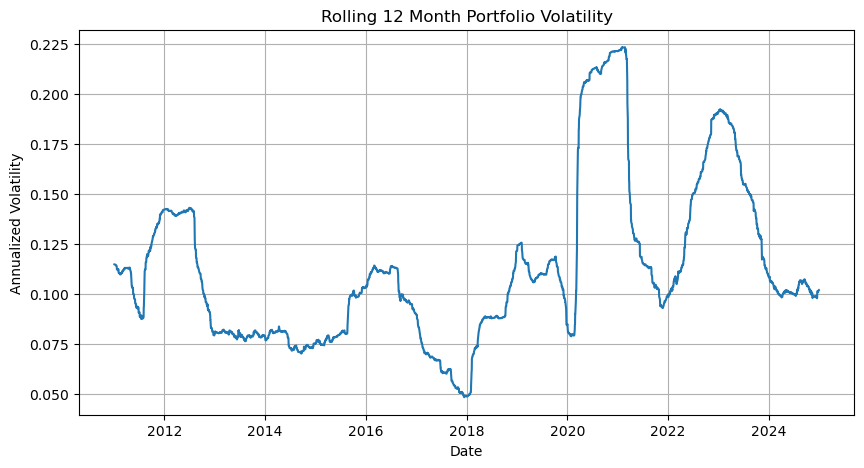

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(rolling_volatility.dropna().index, rolling_volatility.dropna())
plt.title("Rolling 12 Month Portfolio Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.grid(True)
plt.show()

## Annual Returns

Annual returns show how the portfolio performed in each calendar year. This helps compare strong years, weak years, and periods with higher market stress.

In [46]:
annual_returns = portfolio_returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)

annual_returns

Date
2010-12-31    0.140454
2011-12-31    0.086836
2012-12-31    0.128644
2013-12-31    0.196217
2014-12-31    0.146406
2015-12-31    0.024190
2016-12-31    0.087651
2017-12-31    0.177022
2018-12-31   -0.023678
2019-12-31    0.257521
2020-12-31    0.231802
2021-12-31    0.176085
2022-12-31   -0.207047
2023-12-31    0.226149
2024-12-31    0.160307
Freq: YE-DEC, dtype: float64

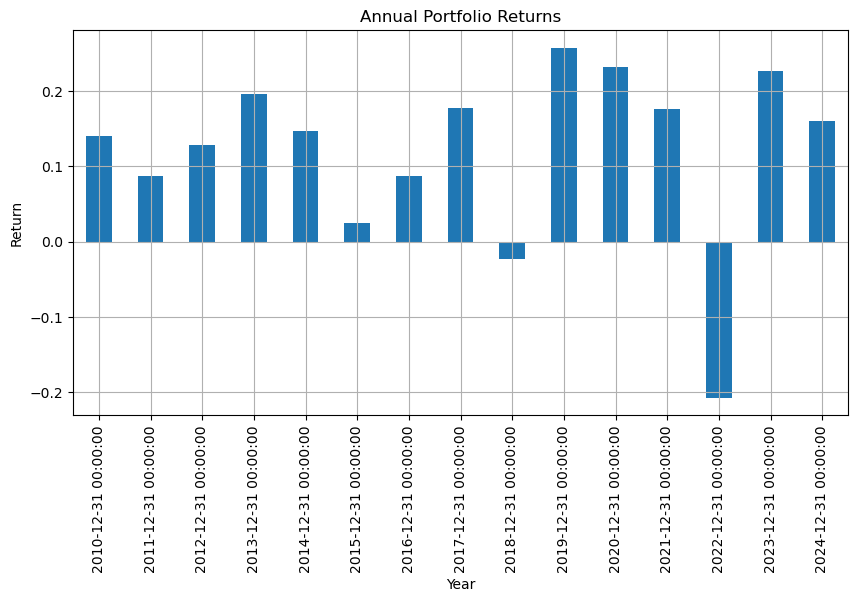

In [48]:
plt.figure(figsize=(10, 5))
annual_returns.plot(kind="bar")
plt.title("Annual Portfolio Returns")
plt.xlabel("Year")
plt.ylabel("Return")
plt.grid(True)
plt.show()

In [50]:
annual_returns.index = annual_returns.index.year

annual_returns

Date
2010    0.140454
2011    0.086836
2012    0.128644
2013    0.196217
2014    0.146406
2015    0.024190
2016    0.087651
2017    0.177022
2018   -0.023678
2019    0.257521
2020    0.231802
2021    0.176085
2022   -0.207047
2023    0.226149
2024    0.160307
dtype: float64

## Asset Returns

Asset returns show how each ETF performed over the full period. This helps identify which holdings contributed most to portfolio growth.

In [53]:
cumulative_assets = (1 + returns).cumprod()

cumulative_assets.tail()

,SPY,QQQ,IWM,IEF,TLT
Date,,,,,
2024-12-23,6.912872,12.895666,4.254888,1.423972,1.475811
2024-12-24,6.989710,13.070529,4.292938,1.424745,1.482052
2024-12-26,6.990175,13.061649,4.336945,1.425826,1.481209
2024-12-27,6.916592,12.888020,4.273721,1.422119,1.469065
2024-12-30,6.837662,12.716612,4.240859,1.430459,1.480871


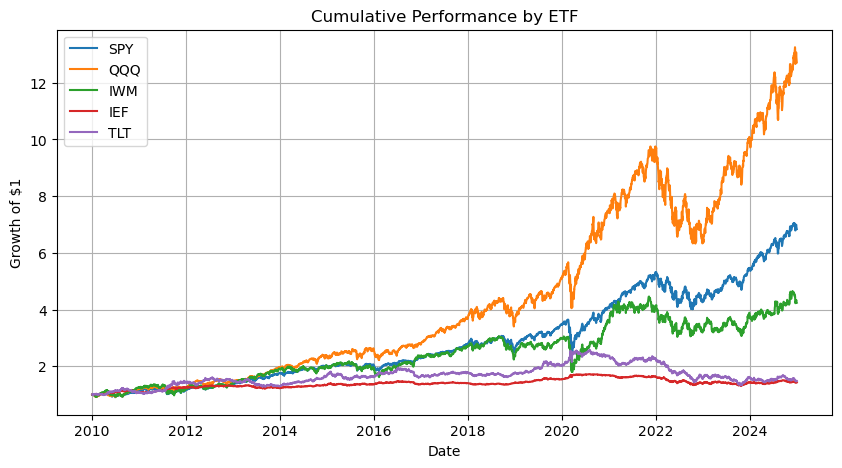

In [55]:
plt.figure(figsize=(10, 5))

for ticker in cumulative_assets.columns:
    plt.plot(cumulative_assets.index, cumulative_assets[ticker], label=ticker)

plt.title("Cumulative Performance by ETF")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

## Asset Risk Metrics

This section compares return and risk across individual ETFs. It helps show which assets drove growth and which assets carried lower volatility.

In [58]:
asset_metrics = pd.DataFrame({
    "Annualized Return": returns.mean() * 252,
    "Annualized Volatility": returns.std() * np.sqrt(252),
    "Sharpe Ratio": (returns.mean() * 252) / (returns.std() * np.sqrt(252))
})

asset_metrics

,Annualized Return,Annualized Volatility,Sharpe Ratio
SPY,0.143060,0.170528,0.838925
QQQ,0.190888,0.204377,0.933999
IWM,0.121447,0.222688,0.545369
IEF,0.026158,0.066946,0.390734
TLT,0.037909,0.152857,0.248002


In [60]:
asset_metrics_formatted = asset_metrics.copy()

asset_metrics_formatted["Annualized Return"] = asset_metrics_formatted["Annualized Return"].map("{:.2%}".format)
asset_metrics_formatted["Annualized Volatility"] = asset_metrics_formatted["Annualized Volatility"].map("{:.2%}".format)
asset_metrics_formatted["Sharpe Ratio"] = asset_metrics_formatted["Sharpe Ratio"].map("{:.2f}".format)

asset_metrics_formatted

,Annualized Return,Annualized Volatility,Sharpe Ratio
SPY,14.31%,17.05%,0.84
QQQ,19.09%,20.44%,0.93
IWM,12.14%,22.27%,0.55
IEF,2.62%,6.69%,0.39
TLT,3.79%,15.29%,0.25


## Correlation Analysis

The correlation matrix shows how ETF returns move together. Lower correlation between stocks and bonds can help reduce overall portfolio risk.

In [63]:
correlation_matrix = returns.corr()

correlation_matrix

,SPY,QQQ,IWM,IEF,TLT
SPY,1.000000,0.928389,0.884671,-0.277005,-0.322405
QQQ,0.928389,1.000000,0.793823,-0.212450,-0.248622
IWM,0.884671,0.793823,1.000000,-0.251836,-0.292605
IEF,-0.277005,-0.212450,-0.251836,1.000000,0.916851
TLT,-0.322405,-0.248622,-0.292605,0.916851,1.000000


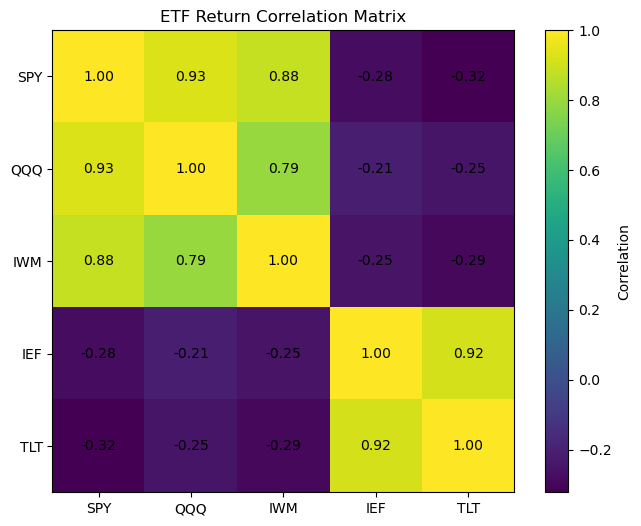

In [65]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("ETF Return Correlation Matrix")

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.show()

## Risk Contribution

Risk contribution shows how much each ETF contributes to total portfolio volatility. This helps identify whether portfolio risk is mainly driven by stocks or bonds.

In [68]:
cov_matrix = returns.cov() * 252

portfolio_volatility = np.sqrt(weights.T @ cov_matrix @ weights)

marginal_risk = cov_matrix @ weights / portfolio_volatility
risk_contribution = weights * marginal_risk
risk_contribution_pct = risk_contribution / portfolio_volatility

risk_contribution_table = pd.DataFrame({
    "Weight": weights,
    "Risk Contribution": risk_contribution_pct
})

risk_contribution_table

,Weight,Risk Contribution
SPY,0.50,0.692975
QQQ,0.15,0.242806
IWM,0.05,0.081138
IEF,0.20,-0.005237
TLT,0.10,-0.011682


In [70]:
risk_contribution_formatted = risk_contribution_table.copy()

risk_contribution_formatted["Weight"] = risk_contribution_formatted["Weight"].map("{:.2%}".format)
risk_contribution_formatted["Risk Contribution"] = risk_contribution_formatted["Risk Contribution"].map("{:.2%}".format)

risk_contribution_formatted

,Weight,Risk Contribution
SPY,50.00%,69.30%
QQQ,15.00%,24.28%
IWM,5.00%,8.11%
IEF,20.00%,-0.52%
TLT,10.00%,-1.17%


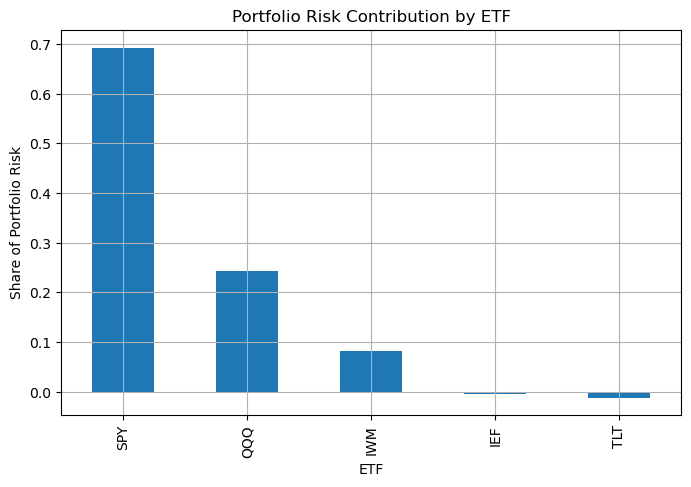

In [72]:
plt.figure(figsize=(8, 5))
risk_contribution_pct.plot(kind="bar")
plt.title("Portfolio Risk Contribution by ETF")
plt.xlabel("ETF")
plt.ylabel("Share of Portfolio Risk")
plt.grid(True)
plt.show()

## Benchmark Comparison

The portfolio is compared with SPY to evaluate whether diversification reduced risk and drawdowns relative to broad U.S. equities.

In [75]:
benchmark_returns = returns["SPY"]

comparison = pd.DataFrame({
    "Portfolio": portfolio_returns,
    "SPY": benchmark_returns
})

cumulative_comparison = (1 + comparison).cumprod()

cumulative_comparison.head()

,Portfolio,SPY
Date,,
2010-01-05,1.002676,1.002647
2010-01-06,0.999923,1.003353
2010-01-07,1.002668,1.007588
2010-01-08,1.006051,1.010941
2010-01-11,1.005518,1.012353


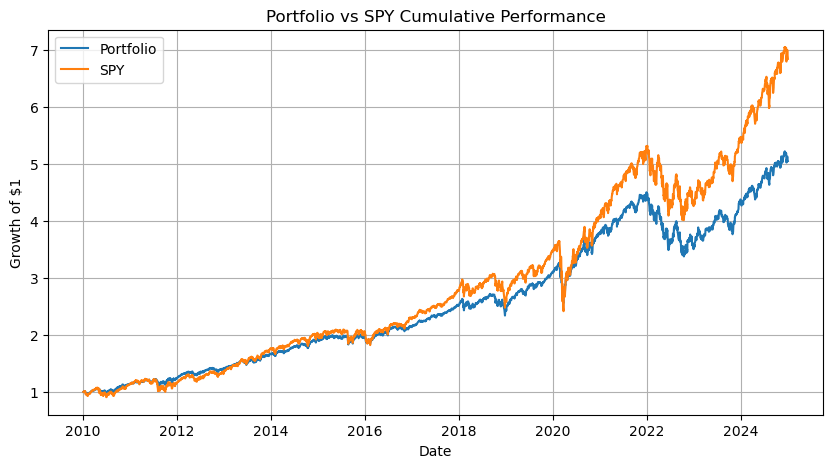

In [77]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_comparison.index, cumulative_comparison["Portfolio"], label="Portfolio")
plt.plot(cumulative_comparison.index, cumulative_comparison["SPY"], label="SPY")
plt.title("Portfolio vs SPY Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
comparison_metrics = pd.DataFrame({
    "Annualized Return": comparison.mean() * 252,
    "Annualized Volatility": comparison.std() * np.sqrt(252),
    "Sharpe Ratio": (comparison.mean() * 252) / (comparison.std() * np.sqrt(252))
})

comparison_metrics

,Annualized Return,Annualized Volatility,Sharpe Ratio
Portfolio,0.115258,0.118921,0.969202
SPY,0.143060,0.170528,0.838925


## Benchmark Drawdown Comparison

This section compares portfolio drawdowns with SPY drawdowns. The goal is to see whether the bond allocation reduced losses during market declines.

In [82]:
cumulative_comparison = (1 + comparison).cumprod()

running_max_comparison = cumulative_comparison.cummax()
drawdown_comparison = cumulative_comparison / running_max_comparison - 1

drawdown_comparison.head()

,Portfolio,SPY
Date,,
2010-01-05,0.000000,0.0
2010-01-06,-0.002746,0.0
2010-01-07,-0.000008,0.0
2010-01-08,0.000000,0.0
2010-01-11,-0.000530,0.0


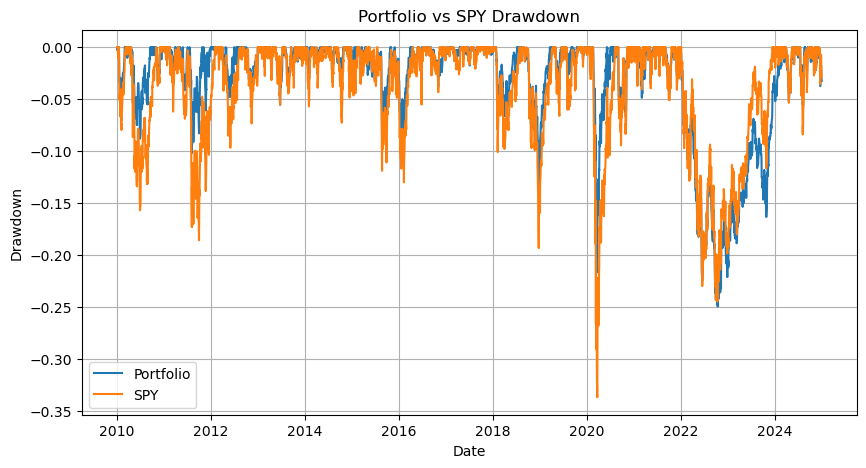

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(drawdown_comparison.index, drawdown_comparison["Portfolio"], label="Portfolio")
plt.plot(drawdown_comparison.index, drawdown_comparison["SPY"], label="SPY")
plt.title("Portfolio vs SPY Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

Worst drawdowns:

In [86]:
drawdown_comparison.min()

Portfolio   -0.249775
SPY         -0.337173
dtype: float64

## Historical Stress Testing

This section evaluates how the portfolio performed during major market stress periods. It helps show whether the bond allocation reduced losses during difficult market environments.

In [90]:
stress_periods = {
    "2011 Debt Ceiling and Eurozone Stress": ("2011-07-01", "2011-10-03"),
    "2015 to 2016 Slowdown": ("2015-08-01", "2016-02-29"),
    "2018 Q4 Selloff": ("2018-10-01", "2018-12-31"),
    "2020 COVID Crash": ("2020-02-19", "2020-03-23"),
    "2022 Rate Hike Shock": ("2022-01-03", "2022-10-14")
}

stress_results = []

for name, dates in stress_periods.items():
    start, end = dates
    
    period_returns = comparison.loc[start:end]
    period_cumulative = (1 + period_returns).cumprod()
    period_drawdown = period_cumulative / period_cumulative.cummax() - 1
    
    stress_results.append({
        "Period": name,
        "Portfolio Return": period_cumulative["Portfolio"].iloc[-1] - 1,
        "SPY Return": period_cumulative["SPY"].iloc[-1] - 1,
        "Portfolio Max Drawdown": period_drawdown["Portfolio"].min(),
        "SPY Max Drawdown": period_drawdown["SPY"].min()
    })

stress_results = pd.DataFrame(stress_results)

stress_results

,Period,Portfolio Return,SPY Return,Portfolio Max Drawdown,SPY Max Drawdown
0,2011 Debt Ceiling and Eurozone Stress,-0.061237,-0.162698,-0.102044,-0.183668
1,2015 to 2016 Slowdown,-0.034582,-0.070194,-0.082190,-0.128207
2,2018 Q4 Selloff,-0.092435,-0.135321,-0.135126,-0.192032
3,2020 COVID Crash,-0.213593,-0.334003,-0.216759,-0.337173
4,2022 Rate Hike Shock,-0.245285,-0.238313,-0.245661,-0.244964


In [92]:
stress_results_formatted = stress_results.copy()

for col in stress_results_formatted.columns[1:]:
    stress_results_formatted[col] = stress_results_formatted[col].map("{:.2%}".format)

stress_results_formatted

,Period,Portfolio Return,SPY Return,Portfolio Max Drawdown,SPY Max Drawdown
0,2011 Debt Ceiling and Eurozone Stress,-6.12%,-16.27%,-10.20%,-18.37%
1,2015 to 2016 Slowdown,-3.46%,-7.02%,-8.22%,-12.82%
2,2018 Q4 Selloff,-9.24%,-13.53%,-13.51%,-19.20%
3,2020 COVID Crash,-21.36%,-33.40%,-21.68%,-33.72%
4,2022 Rate Hike Shock,-24.53%,-23.83%,-24.57%,-24.50%


## Stress Period Asset Returns

This section shows how each ETF performed during the selected stress periods. It helps identify which holdings helped or hurt the portfolio.

In [95]:
stress_asset_results = []

for name, dates in stress_periods.items():
    start, end = dates
    
    period_asset_returns = returns.loc[start:end]
    period_total_returns = (1 + period_asset_returns).prod() - 1
    
    row = {"Period": name}
    for ticker in returns.columns:
        row[ticker] = period_total_returns[ticker]
    
    stress_asset_results.append(row)

stress_asset_results = pd.DataFrame(stress_asset_results)

stress_asset_results

,Period,SPY,QQQ,IWM,IEF,TLT
0,2011 Debt Ceiling and Eurozone Stress,-0.162698,-0.101931,-0.258327,0.114058,0.331986
1,2015 to 2016 Slowdown,-0.070194,-0.079382,-0.158491,0.049996,0.084803
2,2018 Q4 Selloff,-0.135321,-0.167332,-0.202918,0.038559,0.045878
3,2020 COVID Crash,-0.334003,-0.272256,-0.403725,0.063572,0.142264
4,2022 Rate Hike Shock,-0.238313,-0.341374,-0.242773,-0.169907,-0.324103


In [97]:
stress_asset_results_formatted = stress_asset_results.copy()

for col in stress_asset_results_formatted.columns[1:]:
    stress_asset_results_formatted[col] = stress_asset_results_formatted[col].map("{:.2%}".format)

stress_asset_results_formatted

,Period,SPY,QQQ,IWM,IEF,TLT
0,2011 Debt Ceiling and Eurozone Stress,-16.27%,-10.19%,-25.83%,11.41%,33.20%
1,2015 to 2016 Slowdown,-7.02%,-7.94%,-15.85%,5.00%,8.48%
2,2018 Q4 Selloff,-13.53%,-16.73%,-20.29%,3.86%,4.59%
3,2020 COVID Crash,-33.40%,-27.23%,-40.37%,6.36%,14.23%
4,2022 Rate Hike Shock,-23.83%,-34.14%,-24.28%,-16.99%,-32.41%


## Regression Exposure Model

This section estimates how much of the portfolio return is explained by equity and bond market exposure.

In [101]:
import statsmodels.api as sm

regression_data = pd.DataFrame({
    "Portfolio": portfolio_returns,
    "SPY": returns["SPY"],
    "IEF": returns["IEF"],
    "TLT": returns["TLT"]
}).dropna()

X = regression_data[["SPY", "IEF", "TLT"]]
X = sm.add_constant(X)

y = regression_data["Portfolio"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Portfolio   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 1.298e+05
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:11:55   Log-Likelihood:                 21874.
No. Observations:                3772   AIC:                        -4.374e+04
Df Residuals:                    3768   BIC:                        -4.372e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        7.03e-06    1.2e-05      0.587      0.557   -1.64e-05    3.05e-05
SPY            0.7278      0.001    618.757      0.000       0.726       0.730
IEF            0.1940      0.007     27.306      0.000       0.180       0.208
TLT            0.1132      0.003     35.835      0.000       0.107       0.119
==============================================================================
Omnibus:                      222.506   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              822.436
Skew:                          -0.176   Prob(JB):                    2.57e-179
Kurtosis:                       5.260   Cond. No.                         643.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [103]:
regression_results = pd.DataFrame({
    "Coefficient": model.params,
    "P Value": model.pvalues
})

regression_results

,Coefficient,P Value
const,0.000007,5.571216e-01
SPY,0.727818,0.000000e+00
IEF,0.193989,5.941835e-150
TLT,0.113178,2.850037e-242


## Sensitivity Analysis

This section compares the baseline 70/30 portfolio with more conservative and more aggressive stock and bond allocations.

In [106]:
alternative_weights = {
    "60/40 Portfolio": pd.Series({
        "SPY": 0.45,
        "QQQ": 0.10,
        "IWM": 0.05,
        "IEF": 0.30,
        "TLT": 0.10
    }),
    "70/30 Portfolio": pd.Series({
        "SPY": 0.50,
        "QQQ": 0.15,
        "IWM": 0.05,
        "IEF": 0.20,
        "TLT": 0.10
    }),
    "80/20 Portfolio": pd.Series({
        "SPY": 0.60,
        "QQQ": 0.15,
        "IWM": 0.05,
        "IEF": 0.15,
        "TLT": 0.05
    })
}

In [108]:
sensitivity_returns = pd.DataFrame()

for name, w in alternative_weights.items():
    sensitivity_returns[name] = returns.dot(w)

sensitivity_returns.head()

,60/40 Portfolio,70/30 Portfolio,80/20 Portfolio
Date,,,
2010-01-05,0.002983,0.002676,0.002398
2010-01-06,-0.002883,-0.002746,-0.001804
2010-01-07,0.002502,0.002745,0.003083
2010-01-08,0.002920,0.003374,0.003667
2010-01-11,-0.000328,-0.000530,-0.000149


In [110]:
sensitivity_metrics = pd.DataFrame({
    "Annualized Return": sensitivity_returns.mean() * 252,
    "Annualized Volatility": sensitivity_returns.std() * np.sqrt(252),
    "Sharpe Ratio": (sensitivity_returns.mean() * 252) / (sensitivity_returns.std() * np.sqrt(252))
})

sensitivity_metrics

,Annualized Return,Annualized Volatility,Sharpe Ratio
60/40 Portfolio,0.101177,0.101308,0.998705
70/30 Portfolio,0.115258,0.118921,0.969202
80/20 Portfolio,0.126361,0.137067,0.921890


In [112]:
sensitivity_metrics_formatted = sensitivity_metrics.copy()

sensitivity_metrics_formatted["Annualized Return"] = sensitivity_metrics_formatted["Annualized Return"].map("{:.2%}".format)
sensitivity_metrics_formatted["Annualized Volatility"] = sensitivity_metrics_formatted["Annualized Volatility"].map("{:.2%}".format)
sensitivity_metrics_formatted["Sharpe Ratio"] = sensitivity_metrics_formatted["Sharpe Ratio"].map("{:.2f}".format)

sensitivity_metrics_formatted

,Annualized Return,Annualized Volatility,Sharpe Ratio
60/40 Portfolio,10.12%,10.13%,1.00
70/30 Portfolio,11.53%,11.89%,0.97
80/20 Portfolio,12.64%,13.71%,0.92


## Sensitivity Performance Chart

This chart compares cumulative performance across the 60/40, 70/30, and 80/20 portfolios.

In [115]:
sensitivity_cumulative = (1 + sensitivity_returns).cumprod()

sensitivity_cumulative.head()

,60/40 Portfolio,70/30 Portfolio,80/20 Portfolio
Date,,,
2010-01-05,1.002983,1.002676,1.002398
2010-01-06,1.000091,0.999923,1.000590
2010-01-07,1.002593,1.002668,1.003675
2010-01-08,1.005520,1.006051,1.007355
2010-01-11,1.005191,1.005518,1.007205


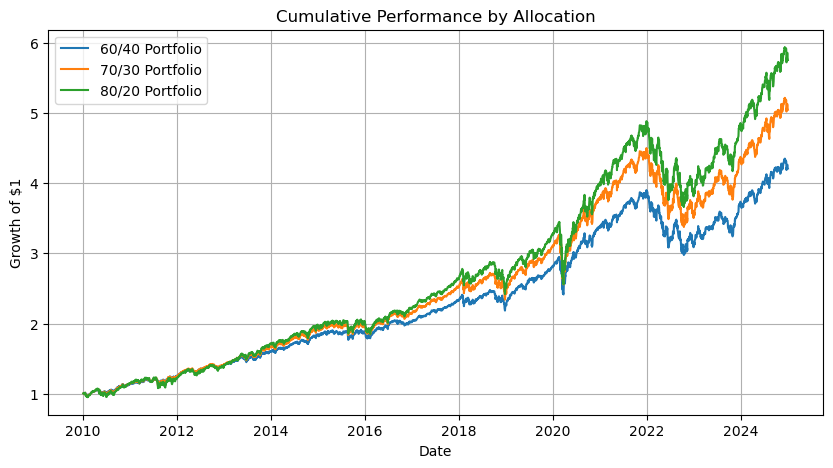

In [117]:
plt.figure(figsize=(10, 5))

for column in sensitivity_cumulative.columns:
    plt.plot(sensitivity_cumulative.index, sensitivity_cumulative[column], label=column)

plt.title("Cumulative Performance by Allocation")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

## Sensitivity Drawdown

This section compares maximum drawdowns across different allocations. Higher stock exposure usually increases return potential, but also increases downside risk.

In [120]:
sensitivity_drawdown = sensitivity_cumulative / sensitivity_cumulative.cummax() - 1

sensitivity_drawdown.min()

60/40 Portfolio   -0.236946
70/30 Portfolio   -0.249775
80/20 Portfolio   -0.257763
dtype: float64

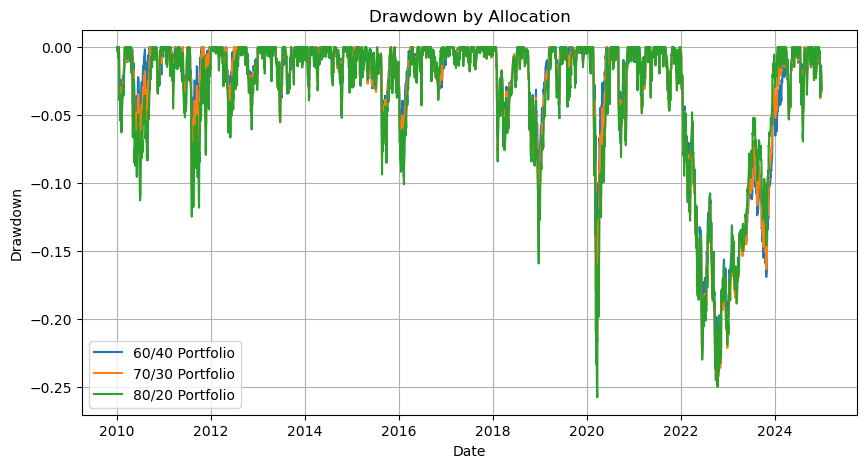

In [122]:
plt.figure(figsize=(10, 5))

for column in sensitivity_drawdown.columns:
    plt.plot(sensitivity_drawdown.index, sensitivity_drawdown[column], label=column)

plt.title("Drawdown by Allocation")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## Key Findings

The 70/30 portfolio produced lower volatility and smaller drawdowns than SPY, but also had lower total return. Its higher risk adjusted performance shows that the bond allocation helped reduce overall risk.

The sensitivity analysis shows that higher equity exposure increased return potential, while lower equity exposure reduced drawdowns. This confirms that portfolio results depend strongly on allocation choices.